In [2]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing  import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [3]:
df = pd.read_csv('C:\\Users\\FDRA\\Documents\\DATA SCIENCE\\CWHDS\\ScikitLearn\\train.csv', usecols=['Age', 'Fare', 'Survived'])

In [4]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.shape

(891, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [7]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [8]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\FDRA\AppData\Local\Temp\ipykernel_10208\1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
X =df.iloc[:, 1:3]
y = df.iloc[:, 0]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

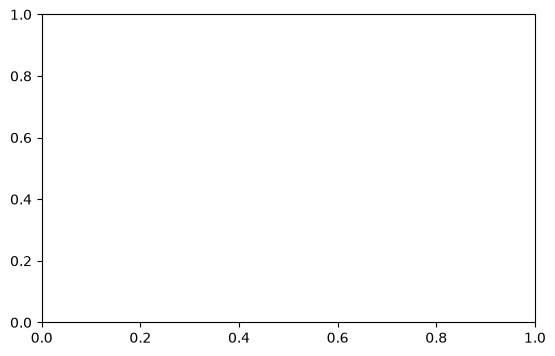

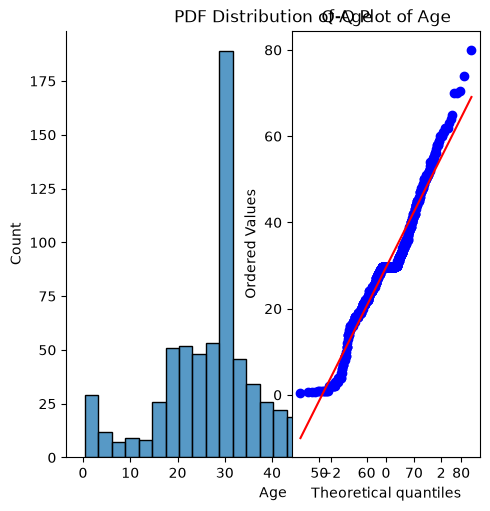

In [12]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.displot(X_train['Age'])
plt.title('PDF Distribution of Age')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Age')
plt.show()

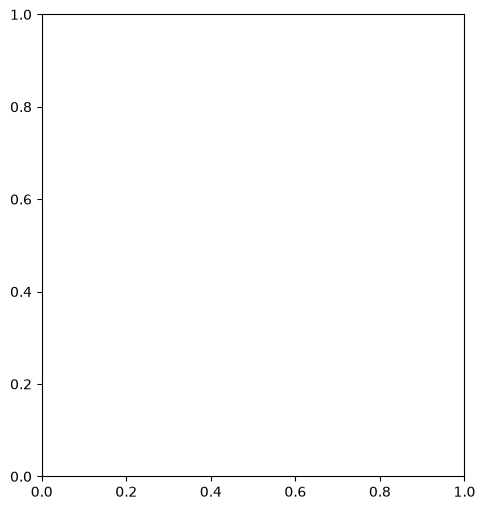

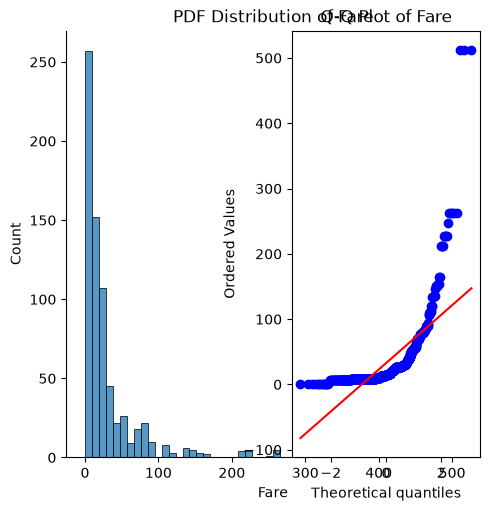

In [13]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.displot(X_train['Fare'])
plt.title('PDF Distribution of Fare')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Fare')

plt.show()

In [14]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [15]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print('Accuracy of Logistic Regression Classifier: ', accuracy_score(y_test, y_pred))
print('Accuracy of Decision Tree Classifier: ', accuracy_score(y_test, y_pred2))

Accuracy of Logistic Regression Classifier:  0.6480446927374302
Accuracy of Decision Tree Classifier:  0.6871508379888268


In [16]:
trf = FunctionTransformer(func=np.log1p)

In [17]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [18]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print('Accuracy of Logistic Regression Classifier: ', accuracy_score(y_test, y_pred))
print('Accuracy of Decision Tree Classifier: ', accuracy_score(y_test, y_pred2))

Accuracy of Logistic Regression Classifier:  0.6815642458100558
Accuracy of Decision Tree Classifier:  0.6815642458100558


In [19]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('Cross Validation Score of Logistic Regression Classifier: ', np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print('Cross Validation Score of Decision Tree Classifier: ', np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

Cross Validation Score of Logistic Regression Classifier:  0.678027465667915
Cross Validation Score of Decision Tree Classifier:  0.6622097378277154


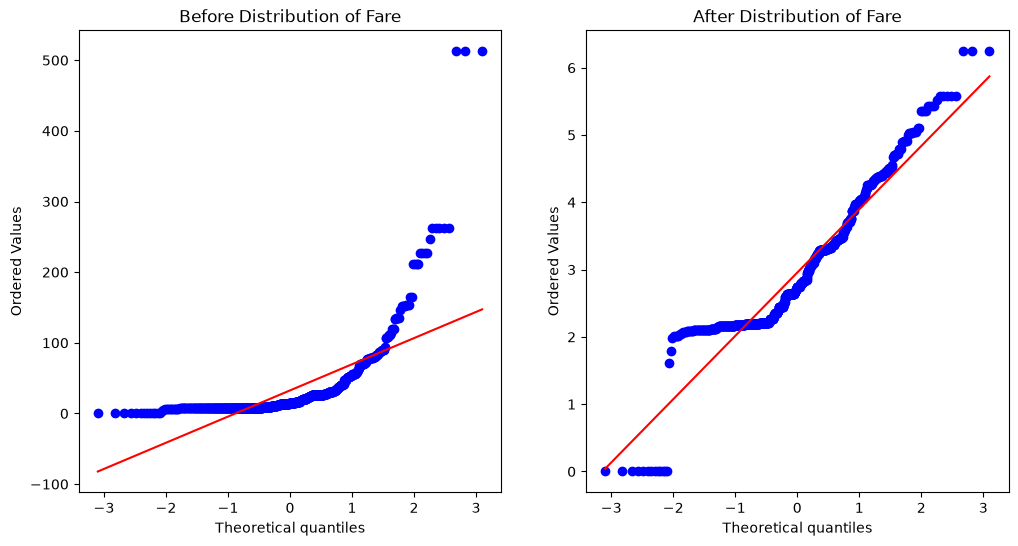

In [24]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Before Distribution of Fare')

plt.subplot(122)
stats.probplot(X_train_transformed["Fare"], dist="norm", plot=plt)
plt.title('After Distribution of Fare')
plt.show()

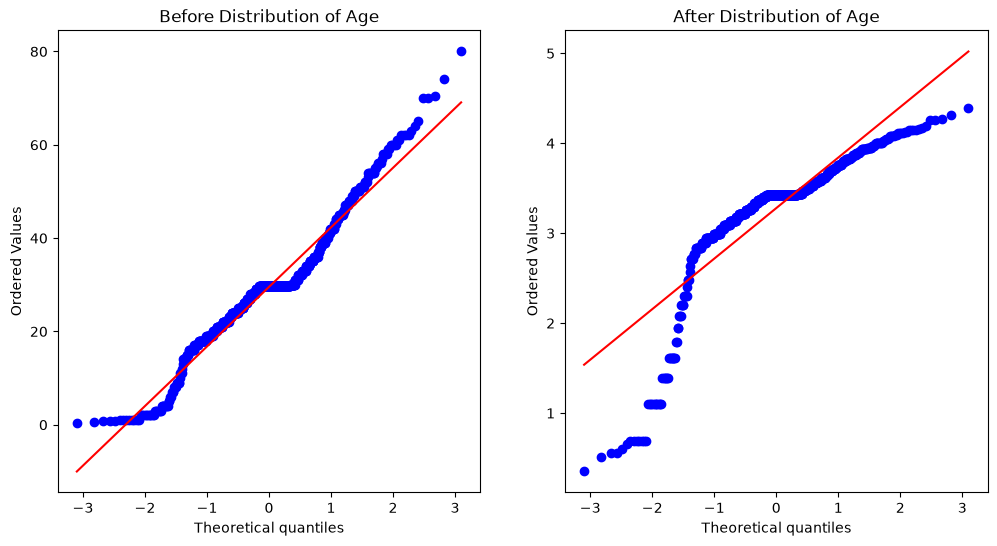

In [25]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Before Distribution of Age')

plt.subplot(122)
stats.probplot(X_train_transformed["Age"], dist="norm", plot=plt)
plt.title('After Distribution of Age')
plt.show()


In [26]:
tfr2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_transformed2 = tfr2.fit_transform(X_train)
X_test_transformed2 = tfr2.transform(X_test)

In [27]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print('Accuracy of Logistic Regression Classifier: ', accuracy_score(y_test, y_pred))
print('Accuracy of Decision Tree Classifier: ', accuracy_score(y_test, y_pred2))

Accuracy of Logistic Regression Classifier:  0.6703910614525139
Accuracy of Decision Tree Classifier:  0.6536312849162011


In [28]:
X_transformed2 = tfr2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('Cross Validation Score of Logistic Regression Classifier: ', np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print('Cross Validation Score of Decision Tree Classifier: ', np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

Cross Validation Score of Logistic Regression Classifier:  0.6712609238451936
Cross Validation Score of Decision Tree Classifier:  0.6610861423220974


In [29]:
def apply_log_transformation(X):
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]
    
    trf = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Cross Validation Score of Logistic Regression Classifier: ", np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Before Distribution of Fare')
    
    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist="norm", plot=plt)
    plt.title('After Distribution of Fare')
    plt.show()

Cross Validation Score of Logistic Regression Classifier:  0.6712609238451936


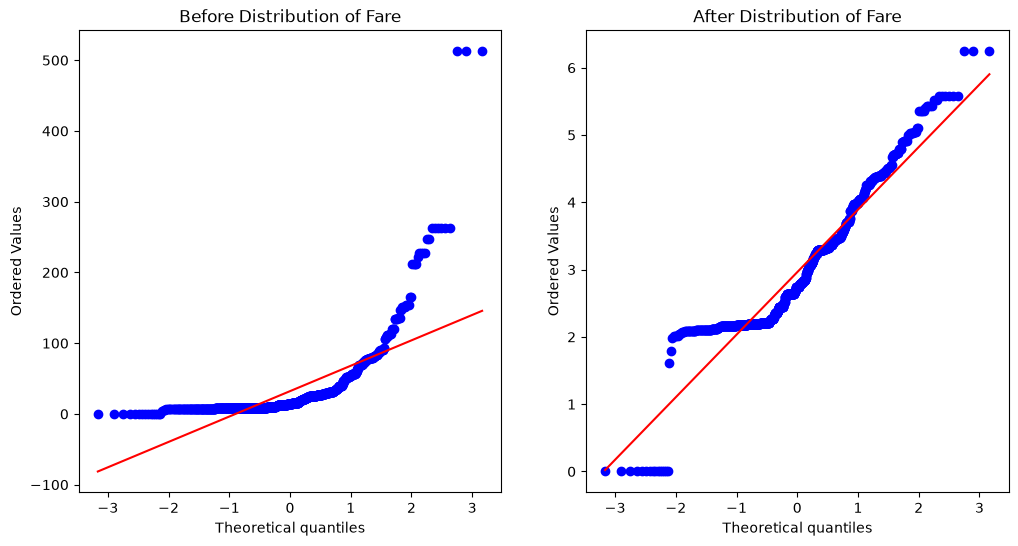

In [41]:
apply_log_transformation(lambda x: np.sin(x))